# Trabajo Práctico 2: Armado de un esquema de aprendizaje automático

En el Trabajo Práctico final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`.   
El conjunto de datos a utilizar está en `("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")`.

Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

# Orientación general del Trabajo Práctico 2

En este trabajo práctico vamos a resolver un problema de **clasificación supervisada**.

El objetivo no es solamente entrenar modelos, sino recorrer el flujo completo de trabajo:

1. Comprender el problema y el dataset.
2. Identificar la variable objetivo.
3. Analizar si las clases están balanceadas.
4. Separar datos de entrenamiento y evaluación.
5. Entrenar modelos de clasificación.
6. Ajustar hiperparámetros con validación cruzada.
7. Evaluar los modelos con métricas apropiadas.
8. Comparar modelos y justificar una recomendación final.

A lo largo del trabajo vamos a intentar responder una pregunta central:

> ¿Qué modelo recomendaríamos usar para este problema y con qué evidencia lo justificaríamos?


# Evaluación con métricas

Para cada modelo evaluado deberíamos reportar, como mínimo:

- accuracy;
- precision;
- recall;
- F1-score;
- matriz de confusión.

Pero además debemos interpretar esos números.

Preguntas orientadoras:

1. ¿El modelo clasifica igual de bien ambas clases?
2. ¿Hay muchos falsos positivos?
3. ¿Hay muchos falsos negativos?
4. ¿Qué métrica parece más relevante para este problema?
5. ¿La accuracy alcanza para decidir o necesitamos mirar otras métricas?

Recordemos que, en problemas con clases desbalanceadas, la accuracy puede ocultar errores importantes.


# Análisis exploratorio mínimo

Antes de entrenar modelos, revisemos:

1. Tamaño del dataset.
2. Nombre y tipo de las variables.
3. Valores faltantes.
4. Distribución de la variable `TARGET`.
5. Posible desbalance de clases.

En particular, para `TARGET` deberíamos calcular:

```python
df["TARGET"].value_counts()
df["TARGET"].value_counts(normalize=True)
```

Si una clase aparece mucho más que la otra, la accuracy puede ser engañosa. En ese caso, deberemos mirar también precision, recall, F1-score y matriz de confusión.


## Antes de empezar: costo del error

Como el problema está relacionado con la aprobación de préstamos o créditos, no todos los errores tienen el mismo significado.

Conviene pensar desde el comienzo:

- **Falso positivo:** el modelo recomienda aprobar un préstamo que no debería aprobarse.
- **Falso negativo:** el modelo recomienda rechazar un préstamo que sí debería aprobarse.

Preguntas para tener presentes durante todo el trabajo:

- ¿Cuál de estos errores sería más costoso para el banco?
- ¿Cuál sería más perjudicial para el cliente?
- ¿Qué métrica nos ayudaría a controlar mejor cada tipo de error?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Agregar las librerías que hagan falta
from sklearn.model_selection import train_test_split

## Recomendación sobre la partición Train/Test

Como estamos trabajando con un problema de clasificación, conviene que la proporción de clases sea parecida en entrenamiento y test.

Para eso podemos usar:

```python
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

El argumento `stratify=y` ayuda a conservar la proporción de clases en ambas particiones.


## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [2]:
#dataset = pd.read_csv("./data/loan_data.csv", comment="#")
dataset = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")


# División entre instancias y etiquetas
X, y = dataset.iloc[:, 1:], dataset.TARGET


In [3]:
print(X, y)

       LOAN   MORTDUE     VALUE   YOJ  DEROG  DELINQ       CLAGE  NINQ  CLNO  \
0      4700   88026.0  115506.0   6.0    0.0     0.0  182.248332   0.0  27.0   
1     19300   39926.0  101208.0   4.0    0.0     0.0  140.051638   0.0  14.0   
2      5700   71556.0   79538.0   2.0    0.0     0.0   92.643085   0.0  15.0   
3     13000   44875.0   57713.0   0.0    1.0     0.0  184.990324   1.0  12.0   
4     19300   72752.0  106084.0  11.0    0.0     0.0  193.707100   1.0  13.0   
...     ...       ...       ...   ...    ...     ...         ...   ...   ...   
1849  53400  228236.0  305514.0   6.0    0.0     0.0   11.148069   0.0   2.0   
1850  53600  235895.0  299772.0   5.0    0.0     0.0  112.748282   7.0  22.0   
1851  53600  208197.0  297280.0   4.0    1.0     1.0  160.485251   2.0  29.0   
1852  65500  205156.0  290239.0   2.0    0.0     0.0   98.808206   1.0  21.0   
1853  77400   87651.0  224630.0   9.0    0.0     2.0   73.469630   3.0  13.0   

         DEBTINC  
0      29.209023  
1


Documentación:

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponible para hacer la predicción?
4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?

**No hace falta escribir código para responder estas preguntas.**

### Exploración del dataset

1. Dimensiones del dataset, tipos de cada variable y primeras filas, para saber cuántas instancias y variables tenemos.

In [4]:
# Dimensiones del dataset
print(f"Filas: {dataset.shape[0]}, Columnas: {dataset.shape[1]}")
print()

print(dataset.dtypes)
print()

dataset.head()

Filas: 1854, Columnas: 11

TARGET       int64
LOAN         int64
MORTDUE    float64
VALUE      float64
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object



,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106


Todas las variables son numéricas.

In [5]:
# Estadísticas descriptivas
dataset.describe().round(2)

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00,1854.00
mean,0.17,19111.76,76316.05,107321.09,8.90,0.19,0.32,180.30,1.13,21.86,34.57
std,0.37,11000.35,46227.03,56039.69,7.55,0.70,0.93,84.84,1.66,9.51,9.31
min,0.00,1700.00,5627.00,21144.00,0.00,0.00,0.00,0.49,0.00,0.00,0.84
25%,0.00,12000.00,48984.75,70787.25,3.00,0.00,0.00,116.97,0.00,16.00,29.43
50%,0.00,17000.00,67201.00,94198.00,7.00,0.00,0.00,174.97,1.00,21.00,35.36
75%,0.00,23900.00,93731.50,122976.25,13.00,0.00,0.00,232.26,2.00,27.00,39.36
max,1.00,89800.00,399412.00,512650.00,41.00,10.00,10.00,1168.23,13.00,65.00,144.19


Las estadísticas descriptivas muestras que:
- DEROG y DELINQ tiene media muy baja (0.19 y 0.32) pero máximos de 10, lo que indica que la mayoria de los clientes no tienen incumplimientos, pero una minoría tiene un historial muy deteriorado.

- DEBTINC tiene una media de 34.57 pero el máximo llega a 114.19, lo que sugiere outliers extremos, clientes con deudas que mutiplican varias veces su ingreso.

- VALUE y MORTDUE están en escalas de cientos de miles, muy diferetenes al resto de las variables, lo que refuerza la necesidad de escalar antes de usar modelos lineales como el SGDClassifier.

2. Valores faltantes.

In [6]:
# Valores faltantes por columna
missing = pd.DataFrame({
    'Faltantes': dataset.isnull().sum(),
    'Porcentaje (%)': (dataset.isnull().mean() * 100).round(2)
})
print(missing)


         Faltantes  Porcentaje (%)
TARGET           0             0.0
LOAN             0             0.0
MORTDUE          0             0.0
VALUE            0             0.0
YOJ              0             0.0
DEROG            0             0.0
DELINQ           0             0.0
CLAGE            0             0.0
NINQ             0             0.0
CLNO             0             0.0
DEBTINC          0             0.0


En el dataset no hay valores faltantes.

3. Distribución del target

Distribución absoluta:
TARGET
0    1545
1     309
Name: count, dtype: int64

Distribución relativa:
TARGET
0    0.833
1    0.167
Name: proportion, dtype: float64


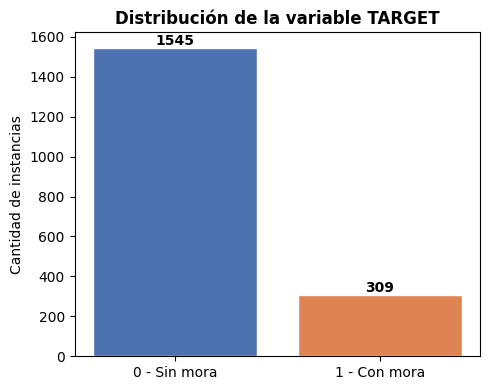

In [7]:
print("Distribución absoluta:")
print(dataset['TARGET'].value_counts())
print()
print("Distribución relativa:")
print(dataset['TARGET'].value_counts(normalize=True).round(3))

# Gráfico
fig, ax = plt.subplots(figsize=(5, 4))
counts = dataset['TARGET'].value_counts()
bars = ax.bar(['0 - Sin mora', '1 - Con mora'], counts.values,
               color=['#4C72B0', '#DD8452'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', fontweight='bold')
ax.set_title('Distribución de la variable TARGET', fontweight='bold')
ax.set_ylabel('Cantidad de instancias')
plt.tight_layout()
plt.show()

Indica que el dataset está desbalanceado:

- Clase 0 (sin mora): 1545 instancias, 83,3%
- Clase 1 (con mora): 309 instancias, 16,7%



4. Ditribución de variables para detectar outliers

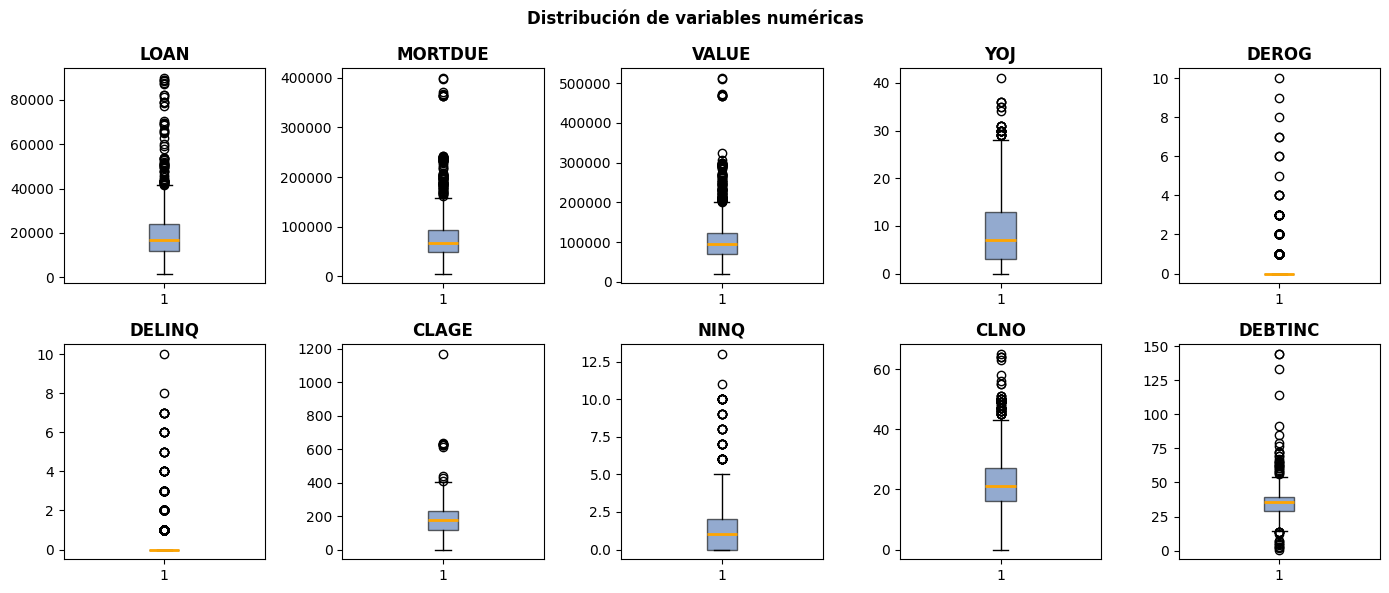

In [8]:
# Boxplots para detectar outliers
features = ['LOAN','MORTDUE','VALUE','YOJ','DEROG','DELINQ','CLAGE','NINQ','CLNO','DEBTINC']

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(dataset[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='orange', linewidth=2))
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Distribución de variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

Los outliers  en LOAN, MORTDUE y VALUE probablemente corresponden a solicitudes de crédito de alto monto, que pueden tener un perfil de riesgo diferente al promedio. En DEBTINC, los valores extremos pueden indicar errores de carga o casos atípicos reales.

Estas diferencias de escala entre variables confirman que el SGDClassifier requiere escalado previo (StandarScaler), mientras que el árbol de decisión no, porque sus divisiones se basan en umbrales relativos, no en distancias.


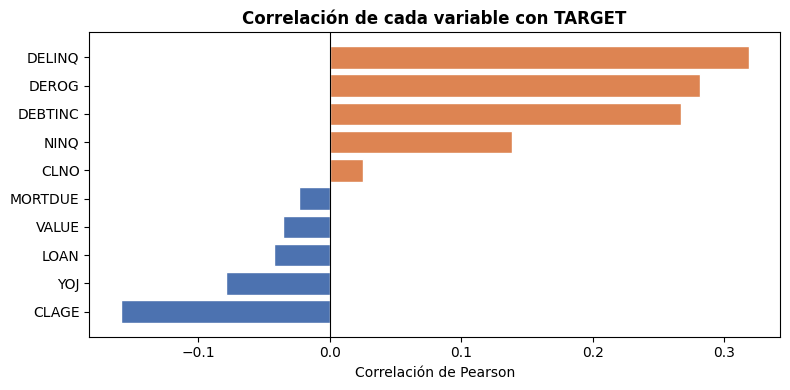

In [9]:
# Correlación de cada variable con TARGET
corr = dataset.corr()['TARGET'].drop('TARGET').sort_values()
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr.values]

plt.figure(figsize=(8, 4))
plt.barh(corr.index, corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada variable con TARGET', fontweight='bold')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

Ninguna variable supera 0.33 de correlación con TARGET, lo que indica que las relaciones lineales simples tienen baja capacidad predictiva individual.
Esto no descarta a SGDClassifier, ya que combina todas las variabels simultáneamente, pero anticipa que un modelo que capture relaciones no lineales, como el árbol de decisión, puede tener ventaja.

Además la correlación de Pearson solo mide relaciones lineales. Variables como DEROG y DELINQ que tienen muchos ceros y pocos valores altos, puede existir un umbral a partir del cual el riesgo sube, sin que eso se refleje como correlación lineal alta.

### Respuestas

**1. ¿De qué se trata el conjunto de datos?**

Es un dataset de solicitudes de préstamos bancarios. Cada fila representa una persona que pidió un préstamos, con sus características financieras. El banco quiere predecir si esa persona va a incumplir el pago o no.

**2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?**

La variable objetivo es TARGET. Toma valores 0 (prestamos fue pagado sin problemas) o 1 (el prestamo entró en mora/default).

**3. ¿Qué información (atributos) hay disponible para hacer la predicción?**

Atributos disponibles:
- LOAN: monto del préstamo solicitado.
- MORTDUE: deuda hipotecaria pendiente.
- VALUE: valor de la propiedad.
- YOJ: años en el trabajo actual.
- DEROG: número de registros derogatorios (manchas crediticas graves).
- DELINQ: número de líneas de crédito con mora.
- CLAGE: antiguedad de la línea de crédito más antigua (meses).
- NINQ: número de líneas de crédito activas.
- DEBTINC: ratio deunda/ingreso.

**4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?**

Los atribuots que parecen más relevantes son DEROG y DELINQ (historial de incumplimientos) DEBTIC (cuánta deuda tiene respecto a su ingreso) y VALUE/ MORTDUE (relación entre lo que vale la propiedad y lo que debe).



## Preguntas orientadoras para el análisis del dataset

Antes de entrenar cualquier modelo, respondamos con texto.La idea es no empezar directamente por el modelo. Primero necesitamos comprender el problema.

**1. ¿De qué se trata este conjunto de datos?**

Es un dataset de solicitudes de préstamos bancarios. Cada fila representa un cliente que pidió un préstamos, con sus características financieras e historial crediticio.


**2. ¿Qué representa la variable `TARGET`?**

La variable TARGET indica si el cliente entró en mora o no. Es una variable binaria: toma valor 0 o 1.


**3. ¿Qué significa la clase `0` y qué significa la clase `1`?**

Significado de clases:
- Clase 0: el préstamo fue pagado correctamente, sin incumplimiento.
- Clase 1: el cliente entró en mora, es decir, no cumplió con los pagos del préstamo.

**4. ¿Cuál es el problema que intenta resolver el banco?**

El banco busca predecir antes de otorgar el préstamo si el cliente va incumplir o no. Esto le permite tomar mejores decisiones de riesgo crediticio, aprobar préstamos con alta probabilidad de repago y rechazar o pedir garantías adicionales cuando el riesgo es alto.

**5. ¿Qué variables predictoras tenemos disponibles?**

Variables predictoras disponibles: diez variables numéricas: LOAN (monto solicitaod), MORTDUE (deuda hipotecaria pendiente), VALUE (valor de la propiedad), YOJ (años en el trabajo actual), DEROG (registros derogatorios), DELINQ (líneas de c´redito en mora), NINQ (consultas crediticas recientes), CLNO (cantidad de líneas de crédito) y DEBTINC (ratio deuda/ingreso).

**6. ¿Qué variables creemos que podrían ser más importantes?**

Variables que podrían ser importantes, de acuerdo al gráfico de correlaciones son: DELINQ, DEROG, y DEBTINC, intuitivamente indica que alguien con historial de mora, manchas crediticas y alta relación deuda/ingreso es un perfil de mayor riesgo.

**7. ¿Hay variables que podrían estar relacionadas entre sí?**

Las variables que podrían estar correlacionadas entre sí, son MORTDUE y VALUE, porque la deuda hipotecaria depende del valor de la propiedad, DELINQ y DEROG también porque ambas reflejan el historial de incumplimientos, solo que en distintos niveles de gravedad. Esta correlación entre predictores se llama multicolinealidad, que puede afectar a los modelos lineales, aunque no a los árboles de decisión.


**8. ¿Qué información adicional nos gustaría tener para comprender mejor el problema?**

La información adicional que estaría bueno tener, sería el ingreso absoluto del cliente (no solo el ratio deuda / ingreso), el tipo de préstamo, la tasa de interés ofrecida, y si el cliente tiene otras deudas fuera de la hipoteca. También seria útil saber si hay sesgo temporal en los datos, es decir si las solicitudes más antiguas tienen más probabilidad de haber entrado en mora por tener más tiempo para hacerlo.


# Modelo lineal con SGDClassifier

En esta parte vamos a usar un clasificador lineal entrenado mediante descenso de gradiente estocástico.

Antes de evaluar resultados, respondamo. Esto conecta directamente con la clase teórica sobre función de costo, optimización y descenso de gradiente.

**1. ¿Qué significa que sea un modelo lineal?**

Que un modelo sea lineal significa que asume que las clases se pueden separar con una línea recta en el espacio de features. Si la relación real es curva o tiene interacciones complejas, el modelo va a tener limitaciones. Por eso después se compara con un árbol de decisión, que sí puede capturar relaciones no lineales.


**2. ¿Qué función de pérdida estamos usando?**

La función pérdida que estamos usando, por defecto es hinge (la de SVM). En el GridSearch se prueba log_loss (equivale a regresión logística) porque nos da probabilidades, lo cual es útil para interpretar el riesgo de default.


**3. ¿Qué hiperparámetros aparecen en la documentación?**

Los hiperparámetros prinicipales que aparecen en la documentación son loss (función de pérdida), alpha (regularización), learning_rate (tasa de aprendizaje), max_iter (número de iteraciones) y class_weight (peso por clase).


**4. ¿Qué valores toma el modelo por defecto?**
Por defecto el modelo usa loss='hinge', alpha=0.0001, learning_rate='optimal' y max_iter=1000. No aplica ningún peso especial a las clases (class_weight=None), lo que lo hace vulnerable al desbalance.

**5. ¿Por qué la tasa de aprendizaje y la regularización pueden afectar el resultado?**

La tasa de aprendizaje controla qué tan grandes son los pasos que da el
modelo al actualizar los pesos en cada iteración. Si es muy alta, el modelo
puede no converger (los pesos oscilan sin estabilizarse). Si es muy baja,
aprende muy lento y puede quedarse atascado en un mínimo no óptimo.

La regularización (alpha) penaliza los pesos grandes para evitar que el
modelo se ajuste demasiado al ruido del train. Un alpha muy alto simplifica
demasiado el modelo (underfitting), mientras que un alpha muy bajo lo deja
sobreajustar. En el GridSearch se prueban distintos valores de alpha
precisamente para encontrar el equilibrio entre sesgo y varianza.





## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

1. Entrenamiento de hiperparámetros por defecto

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

2. Evaluación y métricas

In [12]:
def reporte_metricas(y_true, y_pred, nombre):
    print(f"--- {nombre} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print()
sgd = SGDClassifier(random_state=42, max_iter=1000)
sgd.fit(X_train_scaled, y_train)

y_pred_train = sgd.predict(X_train_scaled)
y_pred_test  = sgd.predict(X_test_scaled)

reporte_metricas(y_train, y_pred_train, 'TRAIN')
reporte_metricas(y_test,  y_pred_test,  'TEST')

--- TRAIN ---
Accuracy:  0.8699
Precision: 0.8462
Recall:    0.2672
F1:        0.4062

--- TEST ---
Accuracy:  0.8733
Precision: 0.8947
Recall:    0.2742
F1:        0.4198



3. Matrices de confusión

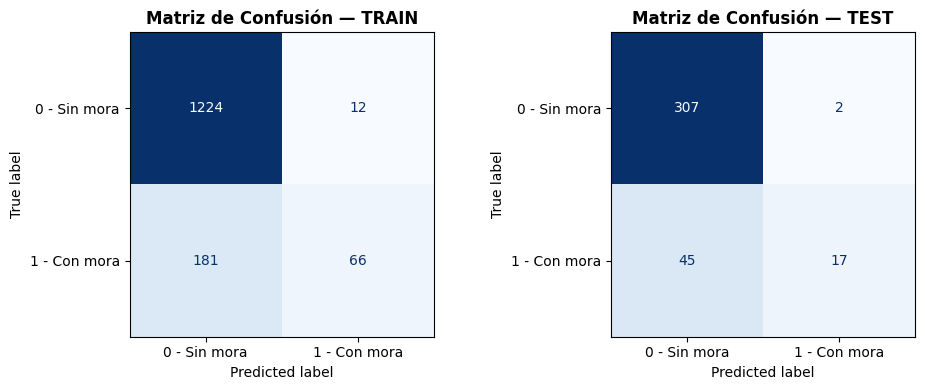

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, titulo in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Matriz de Confusión — TRAIN', 'Matriz de Confusión — TEST']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['0 - Sin mora', '1 - Con mora'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.show()

El accuracy de 0.87 parece alto, pero es engañoso. Como vimos en el Análisis Explotatorio inicial,
el 83% de las instancias son clase 0. Eso significa que un modelo que
prediga siempre "sin mora" obtendría 0.83 de accuracy sin aprender nada. El SGD solo mejora eso en 4 puntos porcentuales, lo cual no justifica confiar en esa métrica sola.

El problema central está en el recall de 0.27, el modelo solo detecta
el 27% de los defaults reales, dejando pasar el 73% restante. Esto se confirma en la matriz
de confusión, en test hay 45 falsos negativos contra solo
17 verdaderos positivos. Es decir que, de cada 10 clientes que van
a entrar en mora, el modelo identifica correctamente a 3 y aprueba a los
otros 7 como si fueran clientes seguros. En un problema de riesgo
crediticio, ese es el error más costoso para el banco.

Esto ocurre porque sin ningún ajuste, el SGD no tiene incentivo para
detectar la clase minoritaria, como los defaults son solo el 17% del
dataset, minimizar errores totales equivale casi a ignorarlos. El F1
de 0.42 confirma el desequilibrio entre precision (0.89) y recall (0.27):
el modelo es muy preciso cuando predice mora, pero rara vez lo hace.
En el siguiente ejercicio se prueban configuraciones con class_weight
y distintas funciones de pérdida para mejorar el recall.

# Búsqueda de hiperparámetros con validación cruzada

Ahora no queremos quedarnos con una sola configuración del modelo.

Vamos a probar varias combinaciones de hiperparámetros y evaluarlas mediante validación cruzada.

Cuando analicemos los resultados de `GridSearchCV`, no miremos solamente el mejor score. También observemos:

1. `best_params_`: mejor combinación de hiperparámetros.
2. `best_score_`: mejor desempeño promedio en validación cruzada.
3. `mean_test_score`: media del score en validación.
4. `std_test_score`: variabilidad entre folds.
5. `mean_train_score`: desempeño promedio en entrenamiento, si está disponible.

Una configuración con media alta y desviación estándar baja suele ser más estable que una configuración con media alta pero gran variabilidad.


### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Se utiliza scoring='accuracy' para la búsqueda de hiperparámetros, tal como
indica la consigna. Sin embargo, dado el desbalance de clases (83%/17%),
la accuracy puede ser engañosa, un modelo que predice siempre clase 0
obtendría 83% sin aprender nada útil. Por eso, además del mejor modelo
según accuracy en CV, se reportan precision, recall y F1 sobre test para
evaluar el comportamiento real frente a los defaults.

Al igual que en el ejercicio 3.2 con el árbol, también se corre un segundo
GridSearch optimizando F1 para comparar si la elección de métrica de scoring
cambia los hiperparámetros seleccionados y cómo impacta en el recall.

Se fija 'learning_rate='optimal' en lugar de incluirlo en la búsqueda porque es
el valor recomendado por la documentación de scikit-learn para SGDClassifier,
calcula automáticamente una tasa adaptada al valor de alpha y al tipo de loss.


In [14]:
param_grid = {
    'loss': ['hinge', 'log_loss', 'modified_huber'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['optimal'],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    SGDClassifier(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print('Mejores parámetros:', grid_search.best_params_)
print('Mejor accuracy en CV:', round(grid_search.best_score_, 4))

Mejores parámetros: {'alpha': 0.01, 'class_weight': None, 'learning_rate': 'optimal', 'loss': 'hinge'}
Mejor accuracy en CV: 0.8712


El GridSearch con 'scoring='accuracy' seleccionó 'loss=hinge, alpha=0.01, class_weight=None'.


In [15]:
grid_search_f1 = GridSearchCV(
    SGDClassifier(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    return_train_score=True,
    n_jobs=-1
)
grid_search_f1.fit(X_train_scaled, y_train)

print('Mejores parámetros:', grid_search_f1.best_params_)
print('Mejor F1 en CV:', round(grid_search_f1.best_score_, 4))

Mejores parámetros: {'alpha': 0.01, 'class_weight': 'balanced', 'learning_rate': 'optimal', 'loss': 'hinge'}
Mejor F1 en CV: 0.5121


El GridSearch con 'scoring='f1'' seleccionó 'loss=hinge, alpha=0.01, class_weight='balanced'.

El GridSearch con accuracy seleccionó loss=hinge, alpha=0.01,
class_weight=None, con accuracy promedio de 0.87 en CV.
El GridSearch con F1 seleccionó los mismos parámetros excepto
class_weight='balanced', con F1 promedio de 0.51 en CV.

La única diferencia entre ambos es el class_weight. Cuando se optimiza
accuracy, el modelo prefiere ignorar la clase minoritaria (class_weight=None)
porque predecir siempre clase 0 ya da un accuracy alto. Cuando se optimiza
F1, el modelo incorpora class_weight='balanced' para poder detectar más
defaults y subir el recall, a costa de bajar algo la precision.


In [16]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[[
    'param_loss', 'param_alpha', 'param_class_weight',
    'mean_test_score', 'std_test_score'
]].sort_values('mean_test_score', ascending=False)

results.columns = ['Loss', 'Alpha', 'Class Weight', 'Accuracy promedio', 'Varianza']
results.round(4)

,Loss,Alpha,Class Weight,Accuracy promedio,Varianza
12,hinge,0.0100,None,0.8712,0.0033
6,hinge,0.0010,None,0.8705,0.0049
7,log_loss,0.0010,None,0.8685,0.0124
8,modified_huber,0.0010,None,0.8658,0.0140
13,log_loss,0.0100,None,0.8631,0.0055
14,modified_huber,0.0100,None,0.8624,0.0142
1,log_loss,0.0001,None,0.8611,0.0184
0,hinge,0.0001,None,0.8517,0.0101
2,modified_huber,0.0001,None,0.8301,0.0467
15,hinge,0.0100,balanced,0.8079,0.0312


In [17]:
#Métricas del mejor modelo
best = grid_search.best_estimator_

y_pred_train = best.predict(X_train_scaled)
y_pred_test  = best.predict(X_test_scaled)

reporte_metricas(y_train, y_pred_train, 'TRAIN')
reporte_metricas(y_test,  y_pred_test,  'TEST')

--- TRAIN ---
Accuracy:  0.8726
Precision: 0.8919
Recall:    0.2672
F1:        0.4112

--- TEST ---
Accuracy:  0.8760
Precision: 1.0000
Recall:    0.2581
F1:        0.4103



El GridSearch con accuracy seleccionó class_weight=None, por lo tanto el modelo no pondera la clase minoritaria y el recall no mejora respecto al modelo por defecto. Esto confirma que optimizar accuracy en un dataset desbalanceado tiende a ignorar la clase 1.




In [33]:
#Métricas F1
best_f1 = grid_search_f1.best_estimator_

y_pred_train_f1 = best_f1.predict(X_train_scaled)
y_pred_test_f1  = best_f1.predict(X_test_scaled)

reporte_metricas(y_train, y_pred_train_f1, 'TRAIN — SGD mejor F1')
reporte_metricas(y_test,  y_pred_test_f1,  'TEST  — SGD mejor F1')

--- TRAIN — SGD mejor F1 ---
Accuracy:  0.8152
Precision: 0.4613
Recall:    0.6518
F1:        0.5403

--- TEST  — SGD mejor F1 ---
Accuracy:  0.7709
Precision: 0.3678
Recall:    0.5161
F1:        0.4295



El GridSearch con F1 seleccionó class_weight='balanced', lo que explica la mejora en recall, el modelo penaliza más los errores sobre la clase minoritaria.

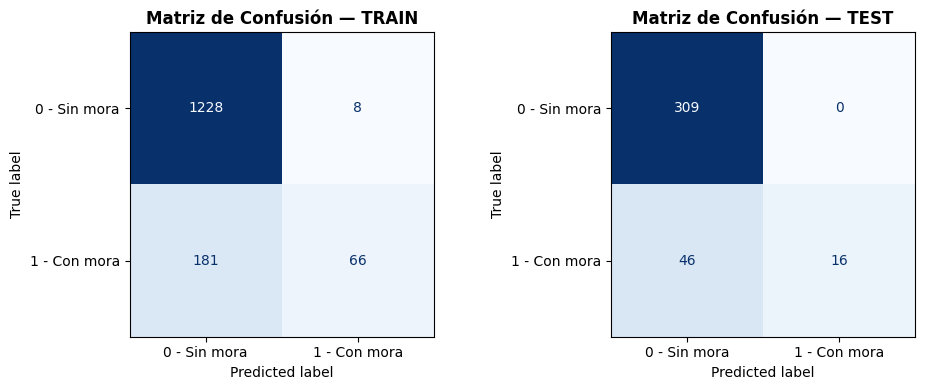

In [18]:
#Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, titulo in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Matriz de Confusión — TRAIN', 'Matriz de Confusión — TEST']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['0 - Sin mora', '1 - Con mora'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.show()

# Árbol de decisión

Ahora vamos a repetir el análisis usando un árbol de decisión.

Este modelo tiene una interpretación diferente al clasificador lineal:

- divide el espacio de atributos mediante reglas;
- puede capturar relaciones no lineales;
- puede sobreajustar si crece demasiado.

Preguntas orientadoras:

**1. ¿Qué profundidad alcanza el árbol por defecto?**

La profundidad que alcanza el árbol es sin límite. Crece hasta que cada hoja contenga instancias de una sola clase o no pueda dividirse más. Esto casi siempre genera sobreajuste porque el árbol "memoriza" el train en lugar de aprender patrones generales.


**2. ¿Hay evidencia de sobreajuste?**

La evidencia en el sobreajuste se confirma con los resultados, pero con profundidad ilimitada es muy esperable ver accuracy muy alta en train (cercana a 1.0) y bastante menor en test. Esa diferencia grande entre train y test es la señal clásica de sobreajuste.

**3. ¿Qué hiperparámetros podemos ajustar?**

Los hiperparámetros que podemos ajustar son criterion, max_depth y min_samples_leaf, que son exactamente los que pide la consigna en el 3.2.

**4. ¿Qué criterio conviene probar: `gini`, `entropy` o `log_loss`?**

Conviene probar los criterios gini, entropy o log_loss. Los tres miden la impureza de un nodo, que tan mezcladas están las clases. Gini es el más rápido computacionalmente, entropy y log_loss suelen dar resultados similares entre sí. En la práctica la diferencia es pequeña, por eso probamos todos en el GridSearch y dejamos que lo datos decidan.


**5. ¿Qué efecto tiene `max_depth`?**

 El efecto que tiene max_depth es que limita hasta dónde puede crecer el árbol. Un valor muy bajo hace que el modelo sea demasiado simple y no capture patrones importantes (underfitting). Un valor muy alto hace que memorice el train (overfitting). El GridSearch nos va a ayudar a encontrar el punto medio.


**6. ¿Qué efecto tiene `min_samples_leaf`?**

El efecto que tiene min_samples_leaf, exigen que cada hoja al menos N instancias para existir. Valores más altos suavizan el árbol y reducen el sobreajuste porque evitan que el modelo cree hojas con muy pocos casos que probablemente son ruido.


### Respuestas

1. En cuanto a la profundidad, es sin límite. Crece hasta que cada hoja contenga instancias de una sola clase o no pueda dividirse más. Esto casi siempre genera sobreajuste porque el árbol "momoriza" el trian en lugar de aprender patrones generales.

2. La evidencia en el sobreajuste se confirma con los resultado, pero con profundidad ilimitada es muy esperable ver accuracy muy alta en train (cercana a 1.0) y bastante menor en test. Esa diferencia grande entre train y test es la señal clásica de sobreajuste.

3. Los hiperparámetros que podemos ajustar son criterion, max_depth y min_samples_leaf, que son exactamente los que pide la consigna en el 3.2.

4. Los criterios gini, entropy o log_loss. Los tres miden la impureza de un nodo, que tan mezcladas están las clases. Gini es el más rápido computacionalmente. entropy y log_loss suelen dar resultados similares entre sí. En la práctica la diferencia es pequeña, por eso los probamos todos en el GridSearch y dejamos que lo datos decidan.


5. El efecto que tiene max_depth es que limita hasta dónde puede crecer el árbol. Un valor muy bajo hace que el modelo sea demasiado simple y no capture patrones importantes (underfitting). Un valor muy alto hace que memorice el train (overfitting). El GridSearch nos va a ayudar a encontrar el punto medio.


6. El efecto que tiene min_samples_leaf, exigen que cada hoja al menos N instancias para existir. Valores más altos suavizan el árbol y reducen el sobreajuste porque evitan que el modelo cree hojas con muy pocos casos que probablemente son ruido.




## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [20]:
y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)

reporte_metricas(y_train, y_pred_train, 'TRAIN')
reporte_metricas(y_test,  y_pred_test,  'TEST')

--- TRAIN ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:        1.0000

--- TEST ---
Accuracy:  0.8841
Precision: 0.6863
Recall:    0.5645
F1:        0.6195



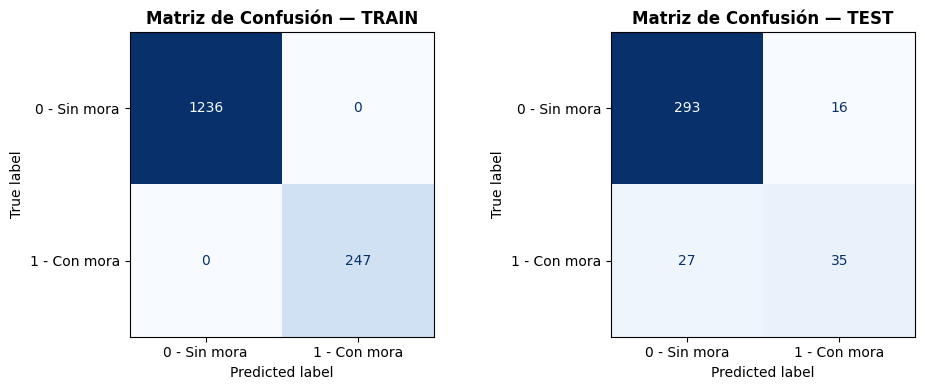

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, titulo in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Matriz de Confusión — TRAIN', 'Matriz de Confusión — TEST']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['0 - Sin mora', '1 - Con mora'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.show()

El árbol sin límite de profundidad obtuvo accuracy, precision, recall y F1 de 1.0 en train, clasificó perfectamente cada instancia. Esto es un aviso, el modelo memorizó el train en lugar de aprender patrones generales.

En test los números caen: recall 0.56, F1 0.62. Esa diferencia entre train (1.0) y test es la evidencia clásica de sobreajuste.

A pesar de eso, el árbol por defecto ya supera al SGD por defecto en F1 (0.62 vs 0.42), lo que sugiere que con ajuste del hiperparámetros tiene potencial para ser el mejor modelo. Eso es lo que se busca en el siguiente punto.

### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced']
}

grid_search_dt_acc = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
grid_search_dt_acc.fit(X_train, y_train)
best_dt_acc = grid_search_dt_acc.best_estimator_

print('Mejores parámetros:', grid_search_dt_acc.best_params_)
print('Mejor accuracy en CV:', round(grid_search_dt_acc.best_score_, 4))

Mejores parámetros: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}
Mejor accuracy en CV: 0.8827


La consigna pide optimizar por accuracy, pero dado el desbalance de clases
analizamos también qué modelo selecciona el GridSearch cuando optimizamos F1,
una métrica más adecuada para clases desbalanceadas. Comparar ambos resultados
nos permite ver si la elección de métrica de scoring cambia los hiperparámetros
seleccionados y cómo impacta en el recall sobre la clase minoritaria.

In [23]:
grid_search_dt_f1 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1',
    return_train_score=True,
    n_jobs=-1
)
grid_search_dt_f1.fit(X_train, y_train)
best_dt_f1 = grid_search_dt_f1.best_estimator_

print('Mejores parámetros:', grid_search_dt_f1.best_params_)
print('Mejor F1 en CV:', round(grid_search_dt_f1.best_score_, 4))

Mejores parámetros: {'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}
Mejor F1 en CV: 0.6078


Los resultados son muy diferentes entre sí. El GridSearch con accuracy seleccionó criterion=gini, max_depth=5,
min_samples_leaf=5 y class_weight=None, con accuracy promedio de 0.88 en CV.
El GridSearch con F1 seleccionó criterion=entropy, max_depth=None,
min_samples_leaf=1 y class_weight=None, con F1 promedio de 0.61 en CV.

El modelo optimizado por accuracy prefiere un árbol poco profundo y con hojas grandes (max_depth=5, min_samples_leaf=5), lo que produce un modelo más conservador y estable.
El modelo optimizado por F1, selecciona un árbol sin límite de
profundidad y sin restricción en las hojas, muy similar al árbol por defecto
del 3.1, lo que sugiere riesgo de sobreajuste.

Con esto se evidencia que al optimizar accuracy en datasets desbalanceados,
el mismo tiende a producir modelos que predicen bien la clase mayoritaria pero dejan  pasar muchos defaults.
Al pptimizar F1 intenta equilibrar precision y recall, pero en este caso el mejor F1 lo logra un árbol que memoriza el train,
lo que no es una solución robusta.

In [25]:
results_dt = pd.DataFrame(grid_search_dt_acc.cv_results_)
results_dt = results_dt[[
    'param_criterion', 'param_max_depth', 'param_min_samples_leaf',
    'param_class_weight',
    'mean_test_score', 'std_test_score'
]].sort_values('mean_test_score', ascending=False)

results_dt.columns = ['Criterion', 'Max Depth', 'Min Samples Leaf', 'Class Weight', 'Accuracy promedio', 'Varianza']
results_dt.round(4).head(10)

,Criterion,Max Depth,Min Samples Leaf,Class Weight,Accuracy promedio,Varianza
5,gini,5,5,None,0.8827,0.0142
36,entropy,None,1,None,0.8807,0.0138
56,log_loss,None,1,None,0.8807,0.0138
8,gini,10,1,None,0.8793,0.0161
52,log_loss,15,1,None,0.8793,0.0210
32,entropy,15,1,None,0.8793,0.0210
4,gini,5,1,None,0.8786,0.0162
12,gini,15,1,None,0.8786,0.0174
0,gini,3,1,None,0.8760,0.0191
26,entropy,5,10,None,0.8760,0.0170


In [27]:
#Métricas del mejor modelo

best_dt_acc = grid_search_dt_acc.best_estimator_

y_pred_train = best_dt_acc.predict(X_train)
y_pred_test  = best_dt_acc.predict(X_test)

reporte_metricas(y_train, y_pred_train, 'TRAIN')
reporte_metricas(y_test,  y_pred_test,  'TEST')

--- TRAIN ---
Accuracy:  0.8955
Precision: 0.9423
Recall:    0.3968
F1:        0.5584

--- TEST ---
Accuracy:  0.8814
Precision: 0.8750
Recall:    0.3387
F1:        0.4884



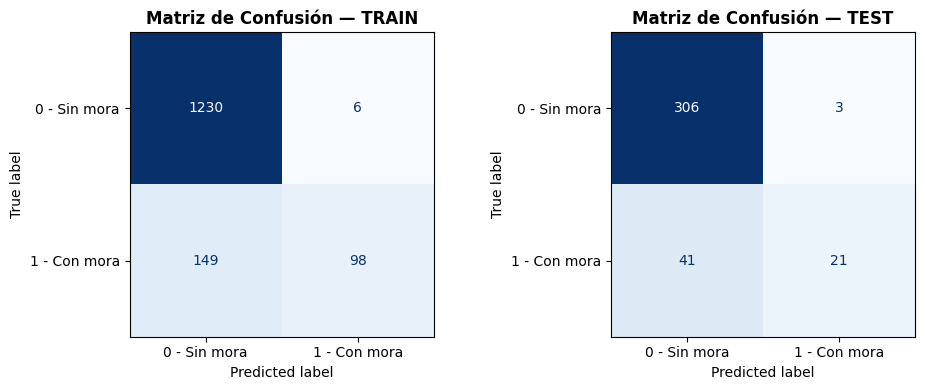

In [28]:
#Matrices de confusión

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, titulo in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Matriz de Confusión — TRAIN', 'Matriz de Confusión — TEST']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['0 - Sin mora', '1 - Con mora'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.show()

### Análisis de resultados

El mejor modelo fue criterion=gini, max_depth=5, min_samples_leaf=5, con
accuracy promedio de 0.88 y varianza 0.014, la más estable.

Limitar max_depth=5 resolvió el sobreajuste del 3.1: el train bajó de 1.0
a 0.89, mucho más cercano al test (0.88).

Sin embargo, el recall bajó a 0.34: el modelo es muy conservador y deja
pasar el 66% de los defaults reales. La matriz confirma lo confirma, con 41 falsos negativos en test contra solo 3 falsos positivos.

Desde la perspectiva del banco, un recall de 0.34 significa que
aproximadamente 2 de cada 3 defaults reales no son detectados: el modelo
los aprueba como si fueran clientes seguros, lo que representa pérdida
directa de capital. Una mejora posible sería usar class_weight='balanced'
con profundidad controlada, o ajustar el umbral de clasificación por debajo
de 0.5 para priorizar el recall a costa de algo de precisión.

In [32]:
# Opción B: ajustar el umbral de clasificación
from sklearn.tree import DecisionTreeClassifier
import numpy as np

proba = best_dt_acc.predict_proba(X_test)[:, 1]
umbral = 0.3  # en lugar de 0.5 por defecto
y_pred_umbral = (proba >= umbral).astype(int)
reporte_metricas(y_test, y_pred_umbral, 'Árbol umbral=0.3')

--- Árbol umbral=0.3 ---
Accuracy:  0.8895
Precision: 0.8889
Recall:    0.3871
F1:        0.5393



Bajar el umbral a 0.3 aumenta el recall a costa de más falsos positivos. En este problema, esa compensación puede ser preferible para el banco, ya que es menos costoso rechazar algunos préstamos buenos que aprobar defaults.

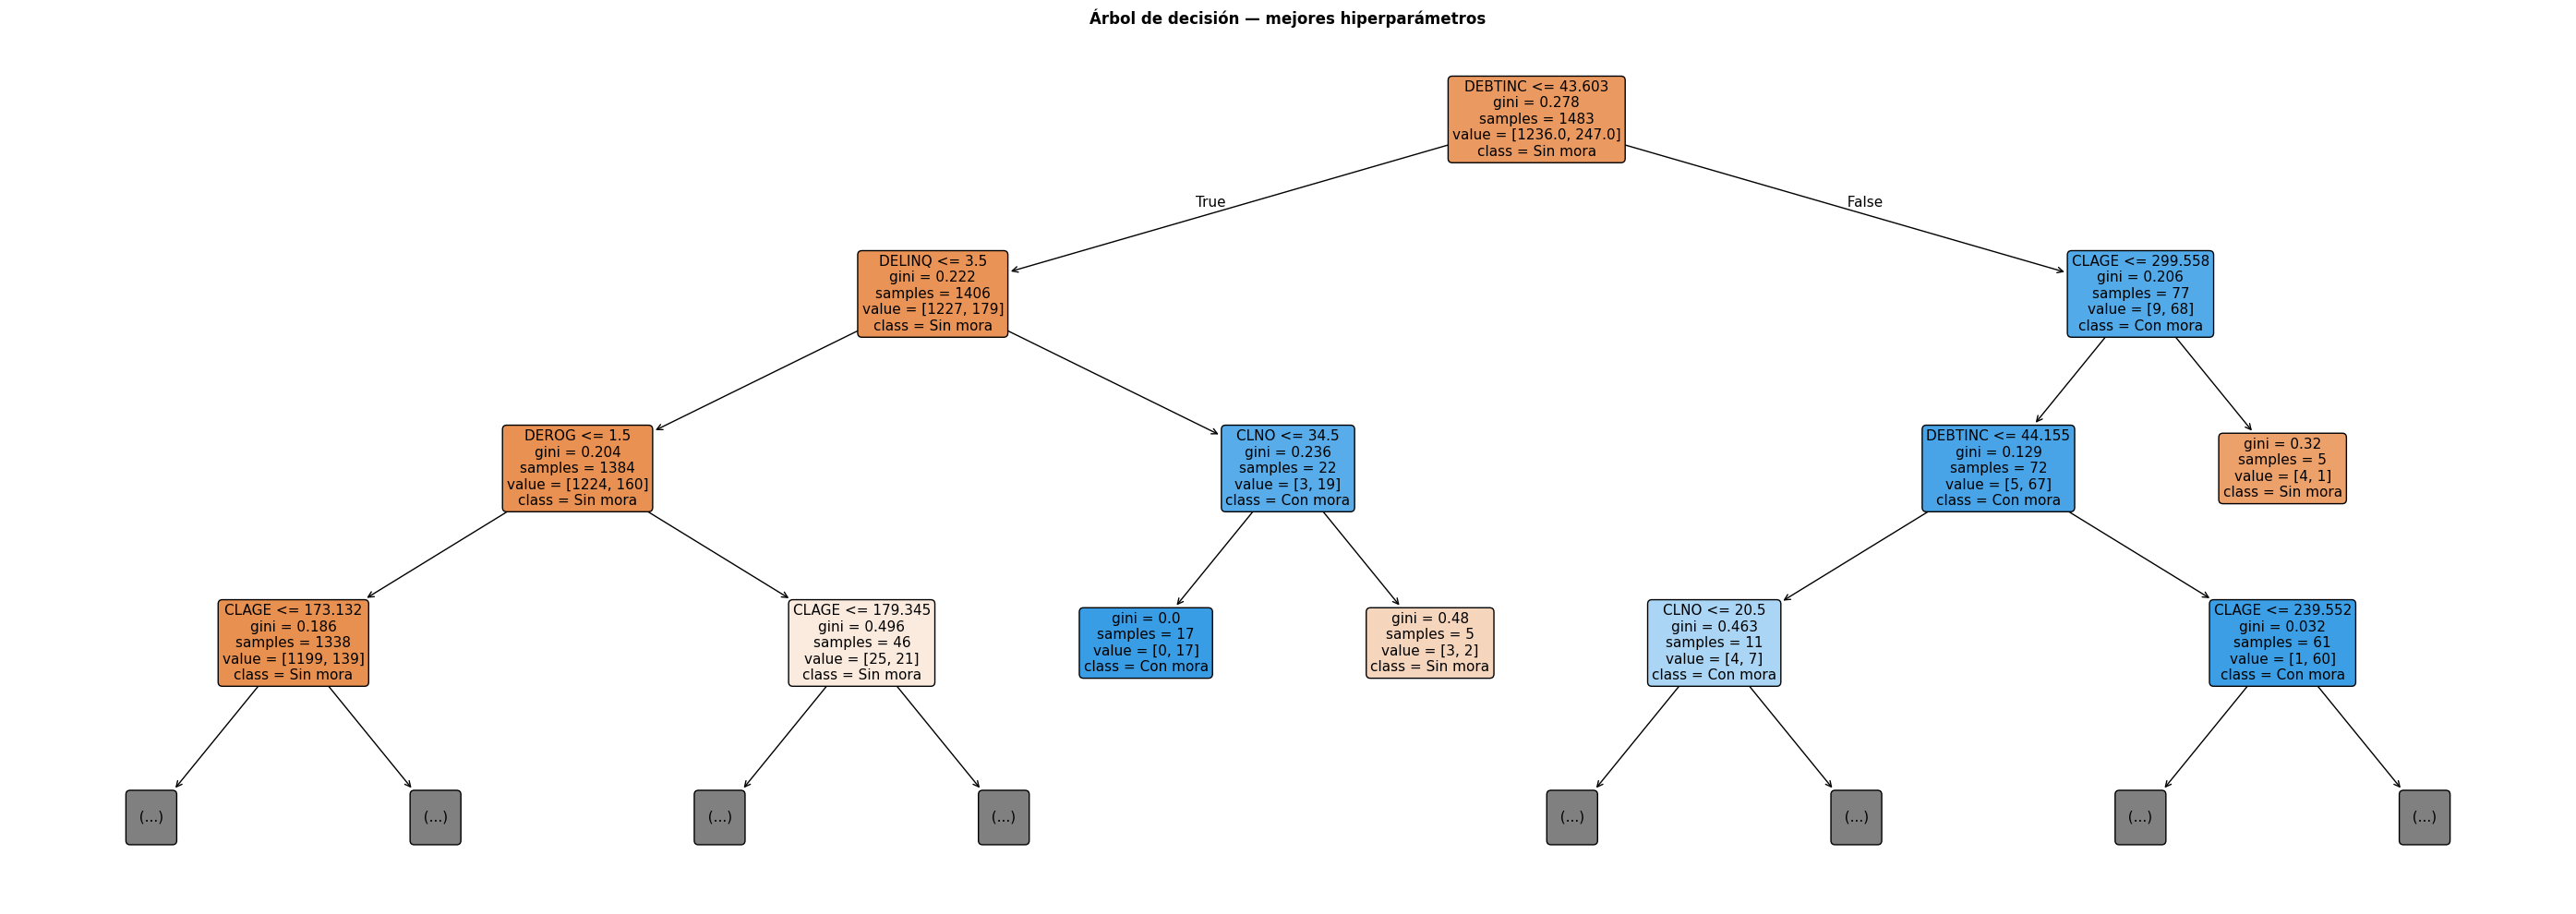

In [29]:
#Árbol de decisión
from sklearn.tree import plot_tree
plt.figure(figsize=(28, 10))
plot_tree(
    best_dt_acc,
    feature_names=X.columns,
    class_names=['Sin mora', 'Con mora'],
    filled=True,
    max_depth=3,        # ← muestra solo los primeros 3 niveles
    fontsize=11,        # ← texto más grande
    rounded=True        # ← bordes redondeados, más legible
)
plt.title('Árbol de decisión — mejores hiperparámetros', fontweight='bold')
plt.tight_layout()
plt.show()

El árbol muestra que la primera división se hace por DEBTINC <= 43.6:
clientes con ratio deuda/ingreso bajo tienden a pagar sin problemas,
mientras que los que superan ese umbral tienen mayoría de defaults.
En la rama de bajo riesgo, la segunda variable más informativa es DELINQ:
tener líneas de crédito en mora es una señal adicional de riesgo incluso
entre clientes con bajo endeudamiento relativo. Esto es consistente con
el análisis exploratorio y con el gráfico de importancia de variables.

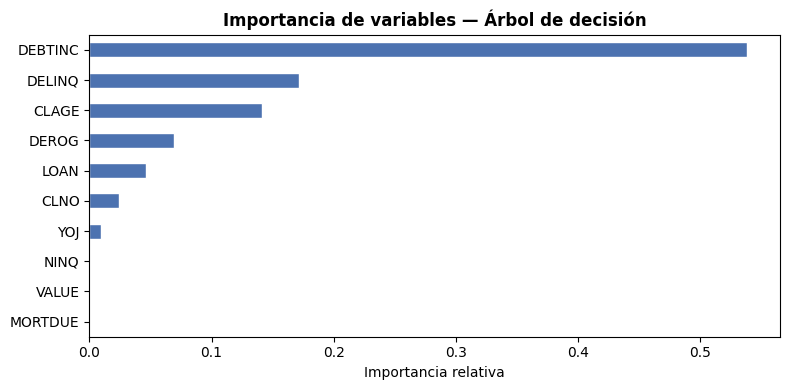

In [30]:
#Importancia de parámetros
importances = pd.Series(
    best_dt_acc.feature_importances_,
    index=X.columns
).sort_values()
plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='#4C72B0', edgecolor='white')
plt.title('Importancia de variables — Árbol de decisión', fontweight='bold')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

DEBTINC (ratio deuda/ingreso) es por lejos la variable más importante con 0.54, seguida por DELINQ (0.17) y CLAGE (0.14). Esto significa que el árbol usa principalmente esas tres variables para tomar sus decisiones.
Esto es interesante comparado con el gráfico de correlaciones del Ejercicio 1, donde DELINQ y DEROG lideraban. El árbol coincide en que DELINQ es relevante, pero le da mucho más peso a DEBTINC de lo que sugería la correlación lineal, lo cual confirma que DEBTINC tiene una relación no lineal con el TARGET que la correlación de Pearson no capturaba bien.
VALUE, MORTDUE y NINQ tienen importancia casi nula, el árbol prácticamente no las usa para decidir.

# Conclusión final del trabajo práctico

Para cerrar el TP, escribamos una conclusión breve respondiendo:

1. ¿Cuál fue el mejor modelo encontrado?
2. ¿Con qué hiperparámetros?
3. ¿Qué métrica usamos para decidir?
4. ¿Por qué esa métrica es adecuada para este problema?
5. ¿El modelo parece estable entre folds?
6. ¿Hay señales de sobreajuste?
7. ¿Qué tipo de error nos preocupa más: falso positivo o falso negativo?
8. ¿Recomendaríamos usar este modelo en un contexto real? ¿Qué advertencias haríamos?

La respuesta no debería limitarse a copiar números. Debe justificar la decisión usando las métricas y el significado del problema.


# Sugerencia opcional: tabla comparativa final

Podemos resumir los resultados en una tabla como esta:

| Modelo | Mejor configuración | Accuracy test | Precision | Recall | F1 | Comentario |
|---|---|---:|---:|---:|---:|---|
| SGDClassifier | ... | ... | ... | ... | ... | ... |
| DecisionTreeClassifier | ... | ... | ... | ... | ... | ... |

Esta tabla ayuda a comparar modelos de manera ordenada.


### Tabla Comparativa


In [34]:
tabla = pd.DataFrame({
    'Modelo': [
        'SGD default',
        'SGD GridSearch (accuracy)',
        'SGD GridSearch (F1)',
        'Árbol default',
        'Árbol GridSearch (accuracy)'
    ],
    'Config': [
        'loss=hinge, α=0.0001, cw=None',
        'loss=hinge, α=0.01, cw=None',
        'loss=hinge, α=0.01, cw=balanced',
        'sin límite, gini, cw=None',
        'max_depth=5, gini, msl=5, cw=None'
    ],
    'Accuracy test': [0.8733, 0.8733, 0.68, 0.8841, 0.8814],
    'Precision':     [0.8947, 0.8947, 0.30, 0.6863, 0.8750],
    'Recall':        [0.2742, 0.2742, 0.66, 0.5645, 0.3387],
    'F1':            [0.4198, 0.4198, 0.42, 0.6195, 0.4884],
    'Observación':   [
        'Recall muy bajo',
        'Igual al default (cw=None no ayuda)',
        'Mejor recall, peor accuracy',
        'Sobreajuste claro (train=1.0)',
        'Estable, pero recall insuficiente'
    ]
})
tabla

,Modelo,Config,Accuracy test,Precision,Recall,F1,Observación
0,SGD default,"loss=hinge, α=0.0001, cw=None",0.8733,0.8947,0.2742,0.4198,Recall muy bajo
1,SGD GridSearch (accuracy),"loss=hinge, α=0.01, cw=None",0.8733,0.8947,0.2742,0.4198,Igual al default (cw=None no ayuda)
2,SGD GridSearch (F1),"loss=hinge, α=0.01, cw=balanced",0.6800,0.3000,0.6600,0.4200,"Mejor recall, peor accuracy"
3,Árbol default,"sin límite, gini, cw=None",0.8841,0.6863,0.5645,0.6195,Sobreajuste claro (train=1.0)
4,Árbol GridSearch (accuracy),"max_depth=5, gini, msl=5, cw=None",0.8814,0.8750,0.3387,0.4884,"Estable, pero recall insuficiente"


### Conclusión Final

**1 y 2. Mejor modelo y configuración**

El mejor modelo según accuracy en CV es el árbol de decisión ajustado con criterion=gini, max_depth=5, min_samples_leaf=5 y class_weight=None, con accuracy promedio de 0.88 en validación cruzada y varianza de 0.014.


**3 y 4. Métrica utilizada y por qué**
Se usó accuracy como métrica de selección, tal como indica la consigna. Sin embargo, en un dataset desbalanceado (83%/17%) la accuracy sola es insuficiente para evaluar el modelo, un clasificador que prediga siempre clase 0 obtendría 83% sin aprender nada. Por eso se reportaron también precision, recall y F1, que permiten ver el comportamiento real sobre la clase minoritaria.

** 5. Estabilidad entre folds**
El árbol ajustado mostró una varianza de 0.014 en CV, la más baja de todas las configuraciones probadas, lo que indica que el modelo es estable y no depende fuertemente de cómo se particionan los datos.

**6. Señales de sobreajuste**
El árbol por defecto (Ej 3.1) mostró un sobreajuste claro: métricas de 1.0 eb train y 0.88 en test. Limitar max_dpeth=5 y min_samples_leaf=5 resolvió el problema: el train y test quedaron muy cercanos (0.89 vs 0.88).


**7. Error más preocupante**
El falso negativo es el error más costoso para el banco, aprobar un préstamo que luego entra en mora implica pérdida directa de capital. El modelo ajustado tiene un recall de 0.34 sobre la clase 1, es decir, deja pasar el 66% de los defaults reales. Eso es una limitación importante para su uso en producción.


**8. Recomendación para uso real**
El árbol ajustado es un punto de partida razonable, es interpretable, estable y no sobreajusta. Sin embargo, antes de desplegarlo en producción recomendaría: (a) explorar class_weight='balanced' con profundidad controlada para mejorar el recall, (b) ajustar el umbral de clasificación por debajo de 0.5 para detectar defaults a costa de algo de precision, y (c) evaluar modelos de ensamble como Random Forest o Gradient Boosting, que suelen superar a un árbol individual. El modelo no debería usarse como único criterio de decisión, sino como apoyo al juicio de un analista de crédito.